# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [2]:
## Makes Illustrator recognize text in saved PDF figures:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

# Analysis

In [3]:
idata = az.from_netcdf(RESULTS_DIR / "idata_blood_glucose.nc")
idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

In [4]:
display(az.summary(idata, var_names=["~mu"]).iloc[:20])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.146,0.016,0.115,0.175,0.000,0.000,1745.0,2528.0,1.00
Intercept,1.896,0.057,1.789,2.001,0.001,0.001,2379.0,3057.0,1.00
stage[empa],0.744,0.068,0.612,0.866,0.001,0.001,2686.0,2997.0,1.00
stage[vehicle],0.862,0.069,0.740,0.995,0.001,0.001,2580.0,3007.0,1.00
gtyp[fa/fa],1.485,0.080,1.336,1.637,0.002,0.001,1984.0,2476.0,1.00
sex[M],0.170,0.070,0.044,0.310,0.001,0.001,2974.0,3116.0,1.00
"stage:gtyp[empa, fa/fa]",-0.864,0.082,-1.014,-0.702,0.001,0.001,3824.0,3259.0,1.00
"stage:gtyp[vehicle, fa/fa]",-0.887,0.085,-1.042,-0.722,0.001,0.001,3847.0,3108.0,1.00
"stage:sex[empa, M]",-0.057,0.081,-0.200,0.102,0.001,0.001,3342.0,3352.0,1.00
"stage:sex[vehicle, M]",-0.010,0.083,-0.166,0.142,0.001,0.001,3597.0,2593.0,1.00


# Compute TS

### For each group

In [5]:
t_groups = {
    'baseline':{
        "fa/+:female":   idata.posterior["Intercept"],
        "fa/+:male":   idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/fa:female":   idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:male":   idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["gtyp"],
    },
    'vehicle':{
        "fa/+:female":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="vehicle"),
        "fa/+:male":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="vehicle") + \
                       idata.posterior["sex"] +idata.posterior["stage:sex"].sel({"stage:sex_dim":"vehicle, M"}),
        "fa/fa:female":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="vehicle") + \
                          idata.posterior["gtyp"] + idata.posterior["stage:gtyp"].sel({"stage:gtyp_dim": 'vehicle, fa/fa'}),
        "fa/fa:male":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="vehicle") + \
                        idata.posterior["sex"] + idata.posterior["stage:sex"].sel({"stage:sex_dim":"vehicle, M"}) + \
                        idata.posterior["gtyp"] + idata.posterior["stage:gtyp"].sel({"stage:gtyp_dim": 'vehicle, fa/fa'}),
    },
    'empa':{
        "fa/+:female":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="empa"),
        "fa/+:male":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="empa") + \
                                idata.posterior["sex"] +idata.posterior["stage:sex"].sel({"stage:sex_dim":"empa, M"}),
        "fa/fa:female":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="empa") + \
                                idata.posterior["gtyp"] + idata.posterior["stage:gtyp"].sel({"stage:gtyp_dim": 'empa, fa/fa'}),
        "fa/fa:male":   idata.posterior["Intercept"] + idata.posterior["stage"].sel(stage_dim="empa") + \
                                idata.posterior["sex"] +idata.posterior["stage:sex"].sel({"stage:sex_dim":"empa, M"}) + \
                                idata.posterior["gtyp"] + idata.posterior["stage:gtyp"].sel({"stage:gtyp_dim": 'empa, fa/fa'}),
    }
}

### For change between empa and vehicle (for each group and for averages over sex)

In [9]:
## For each group:
t_change = {k: v - t_groups['vehicle'][k] for k,v in t_groups['empa'].items()}

## For averages over sex:
t_change['fa/fa'] = (t_change["fa/fa:female"] + t_change["fa/fa:male"])/2
t_change['fa/+'] = (t_change["fa/+:female"] + t_change["fa/+:male"])/2

### For difference in the change between sexes

In [10]:
t_sex = {
    'all' : t_change['fa/fa:male'] - t_change['fa/fa:female'],
}

----------

# Show TS

## For groups for each stage

## <font color='red'>Teddy, in the following I plot np.exp(TS) - is the model prediction for actual value of blood glucose?</font>

[]

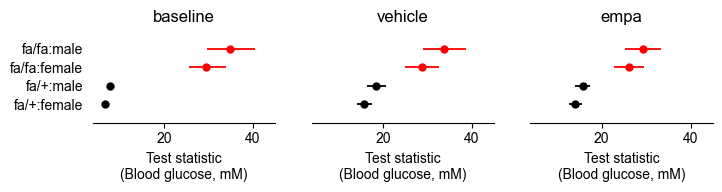

In [7]:
f, axs = plt.subplots(1,3,figsize=(8, 1.2))

for ax, (k,v) in zip(axs, t_groups.items()):
    
    ax = forestplot_oz(ax, 
                       {lbl:np.exp(ts_) for lbl, ts_ in v.items()} #### np.exp(TS)
                      );
    ax.set_title(k);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(Blood glucose, mM)')

    ax.set_xlim(4,45)
axs[1].set_yticks([], [])
axs[2].set_yticks([], [])
# f.savefig(PLOT_DIR / "ts_blood_glucose_groups.pdf", bbox_inches="tight")

## Change between empa and vehicle for difference between sexes

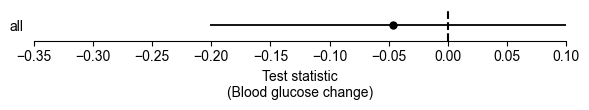

In [11]:
f, ax = plt.subplots(figsize=(6, 1.2))
ax = forestplot_oz(ax, t_sex);

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_xlabel('Test statistic\n(Blood glucose change)')

ax.set_xlim(-0.35, 0.1)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_UrineFlow_groups.pdf", bbox_inches="tight")

## Change between empa and vehicle for all groups and for averages over sexes

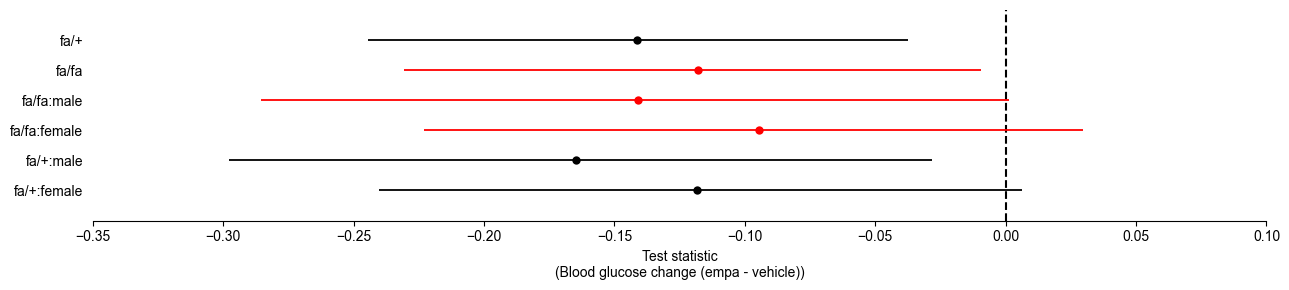

In [10]:
f, ax = plt.subplots(figsize=(13, 3))
ax = forestplot_oz(ax, t_change);

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_xlabel('Test statistic\n(Blood glucose change (empa - vehicle))')

ax.set_xlim(-0.35, 0.1)

f.tight_layout()
# f.savefig(PLOT_DIR / "ts_blood_glucose_change.pdf", bbox_inches="tight")

# Sign probabilities and significance

In [12]:
sp_changes = pd.DataFrame({
    'sign_probability':get_sign_probs(t_change),
    'significance':{k:get_signif(v) for k,v in get_sign_probs(t_change).items()},
})

sp_sex = pd.DataFrame({
    'sign_probability':get_sign_probs(t_sex),
    'significance':{k:get_signif(v) for k,v in get_sign_probs(t_sex).items()},
})

In [14]:
sp_all = pd.concat(objs=(sp_changes,
                 sp_sex), 
                   keys=('empa - vehicle',
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/Blood_glucose.csv')
sp_all

sign_probability significance
contrast       group                                      
empa - vehicle fa/+:female            0.03075             
               fa/+:male              0.00900            *
               fa/fa:female           0.06700             
               fa/fa:male             0.02575             
               fa/fa                  0.01800            *
               fa/+                   0.00575            *
male - female  all                    0.27550